In [1]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt
print(tf.__version__)

2.21.0


SETTING THE CONSTANTS(HYPER PARAMETER)
Hyperparameter= That define key aspect of how the training prcess will be conducted

1 BATCH_SIZE:
it represents the number of training examples utilized in one iteration.In simple terms,during each iteration of training,the model updates its weights based on the subset of the entire dataset. The choice of batch size can affect training speed and memory requirements

2 IMAGE_SIZE
This typically refers to the dimension (width and height) of the input images.The neural network architecture and the training process often depend on the size of input images.it is essential to ensure consistency in image size to feed into the network

3 CHANNEL:
It represents the number of color channels in the input images.For eg RGB images have three channels (RED,GREEN,BLUE).Grayscale images have one channel.The number of channel influences the *****************


IMPORT DATA INTO TENSORFLOW DATASET OBJECT
We will use image_dataset_from_directory api to load all images in tensorflow dataset.
1 directry ="PlantVillage". This Parameter specifies the path to the directry containing your image dataset.In this case,it is assumed that the images are stored in the "PlantVillage" directry
2 seed=123. The seed parameter sets the random seed for data shuffling and transformations.Using a fixed seed ensures reproducibility,meaning that if you run the code with the same seed,you should get the same results.

3 Shuffle=True The shuffle parameter determines whether to shuffle data.When set to true,it shuffles the order of images in each epoch,which is beneficial for training to prevent the model from memorizing the order of data

4 image_size=IMAGE_SIZE,IMAGE_SIZE = the image_size sets the dimensions to which the input images will be resized.the IMAGE_SIZE variable likely holds a specific size,ensuring that all the images rae standardized to the same dimensions befre being fed into the neural network.

5 batch_size=BATCH_SIZE, The batch_size parameter defines the number of images in each batch during training.It is set to the value of the Batch_size variable.Training neural networks in batches helps manage memory efficiently and allows for parallel processing,which can spped up training


In [3]:
BATCH_SIZE = 32
IMAGE_SIZE= 255
CHANNEL=3
EPOCHS =20
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    directory="PlantVillage(1)",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=32
)
class_names=dataset.class_names
class_names

Found 2152 files belonging to 3 classes.


['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

BELOW CODE

32=The batch size,representing the number of images in the batch
255 =the height of each image
255=the width of each image
3= the number of color channel


# single image
This section shows the pixel value of a single image in the batch.It is a 3D tensor representing the color values of each pixel in the image
Each pixel has hree values(RGB) representing the intensity of red,green and blue,repectively
the value range from 0 to 255,where 0 is the absence of color and 255 is the maximum intensity of that color

# label
this part shows the label corresponding to the images in the image.It`s a 1D tensor with a shape of 32 (bcoz our batch size is 32),indicating the label for each image in the batch.The label seems to be integers ranging from 0 to 2

In [4]:
 # doubt
# dataset.take(count) kya karta hai? 
# sol- yeh function hamare dataset mein se count number of images leta hai aur har image ke liye teen cheeze return karta hai
# 1- count number of images ka size+batch size.Agar batch size none hoga toh output mein image ka size(height,width,number of channels) millega
# 2- count number of images ka pixel value.each pixel has 3 values so it is a 3d tensor
# 3 label of each image in a batch. Agar batch size none hoga toh outut mein ek image ki pixel value millegi +us image ka lbel millega.Phir 
# agli image ki pixel value millegi aur us image ka label millega 

for each_image_in_a_batch,label_of_each_image_in_a_batch in dataset.take(1):
            print("shape of each image in a batch",each_image_in_a_batch.shape )
            print("pixels of",2,"image in a batch",each_image_in_a_batch[0])
            print("label of each image in a batch",label_of_each_image_in_a_batch.numpy)
            print()
    
len(class_names) # we have three categories

shape of each image in a batch (32, 255, 255, 3)
pixels of 2 image in a batch tf.Tensor(
[[[141.98236  115.98237  116.98237 ]
  [136.82382  110.823814 111.823814]
  [107.35246   81.35246   82.35246 ]
  ...
  [173.01381  155.01381  151.01381 ]
  [181.93741  163.93741  159.93741 ]
  [195.95111  177.95111  173.95111 ]]

 [[137.87445  111.87446  112.87446 ]
  [136.8248   110.82481  111.82481 ]
  [132.12982  106.129814 107.129814]
  ...
  [175.0646   157.0646   153.0646  ]
  [176.98244  158.98244  154.98244 ]
  [184.96088  166.96088  162.96088 ]]

 [[117.12743   91.12743   92.12743 ]
  [112.31633   86.31633   87.31633 ]
  [144.35968  118.35967  119.35967 ]
  ...
  [176.0387   158.0387   154.0387  ]
  [176.02917  158.02917  154.02917 ]
  [181.049    163.049    159.049   ]]

 ...

 [[107.330246  81.330246  80.330246]
  [145.66852  119.6685   118.6685  ]
  [126.09693  100.09693   99.09693 ]
  ...
  [162.9805   142.9805   141.9805  ]
  [166.96677  146.96677  145.96677 ]
  [170.96283  150.96283 

3

# VISUALIZE SOME OF THE IMAGES FROM OUR DATASET


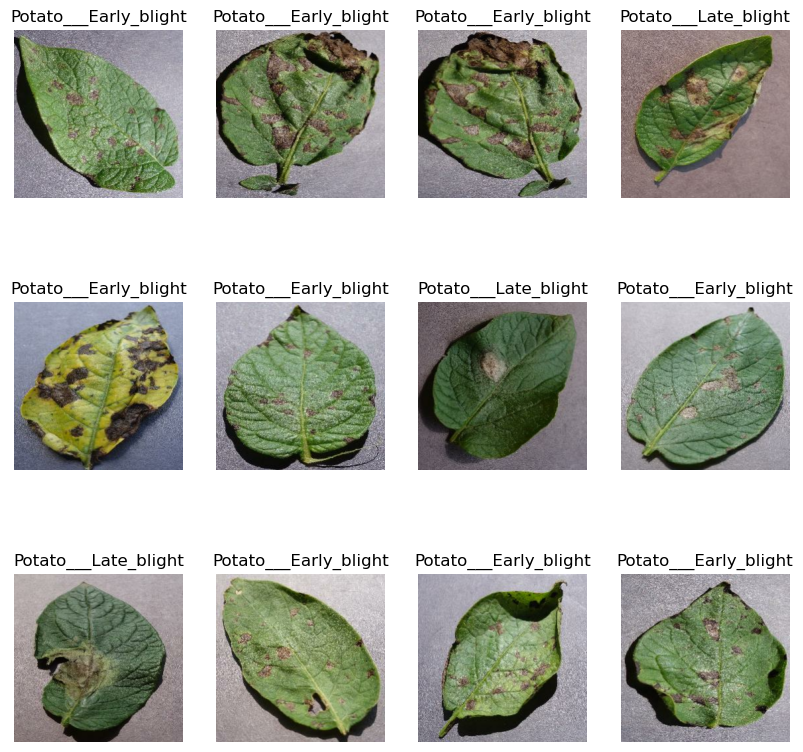

In [5]:
plt.figure(num="int",figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")
        



# FUNCTION TO SPLIT DATASET

we are dividing the dataset into 3 subsets,namely
1 Training: Dataset to be used while training
2 Validation : Dataset to be tested against while training
3 Test : Dataset

In [6]:
len(dataset) # 2152/32=68 ie total_images/batch_size=dataset length

68

In [7]:
train_size=0.8
train_ds=dataset.take(int(train_size*len(dataset)))
len(train_ds)

54

In [8]:
test_ds=dataset.skip(int(train_size*len(dataset)))
len(test_ds)

14

In [9]:
val_size=0.1
val_ds=test_ds.take(int(val_size*len(dataset)))
print(len(val_ds))
test_ds=test_ds.skip(6)
print(len(test_ds))

6
8


In [10]:
# writting function for aboive code
def get_dataset_partition(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=10000):
    assert(train_split+test_split+val_split)==1
    ds_size=len(ds)
    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=12)
    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)
    train_ds=ds.take(train_size)
    val_ds=ds.take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)
    return train_ds,val_ds,test_ds
train_ds,val_ds,test_ds=get_dataset_partition(dataset)
print(len(train_ds),"  ",len(val_ds)," ",len(test_ds))

54    6   8


Cache,Shuffle, and prefetch the Dataset
additional transformation is commonly used in tensorflow to optimize the performance o the input pipeline when training machine learning models

In [11]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)


BUILDING THE MODEL
Creating a Layer for Resizing and Normalization Before we feed our images to network,we should be resizing it to the desired size.Moreover,to improve model performance,we should normalize the image pixel value(keeping them in range 0 and 1 by dividing by 256).This should happen while training as well as inference.Hence we can add that as a layer in our Sequential Model

You might be thinking why do we need to resize (256,256) image again to (256,256).You are right we don`t need to but this willl be usefull when we are done with the training and start using the model for predictions.At that time someone can supply an image that is not (256,256) and this layer will resize it

In [13]:
resize_and_rescale=tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    tf.keras.layers.Rescaling(1./255),
])

DATA AUGMENTATION

Data Augmentation is needed when we have less data,this boosts the accuracy of our model by augmenting the data. So next we will apply data augmentation to train dataset

In [17]:
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])
train_ds=train_ds.map(
    lambda x,y:(data_augmentation(x,training=True),y)).prefetch(buffer_size=tf.data.AUTOTUNE)


MODEL ARCHITECTURE
we use a CNN coupled with a softmax activation in the output layer.we also add the initial layers for resizing,normalization and Data Augmentation

In [21]:
input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNEL)
n_classes=3
model=models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32,kernel_size=(3,3),activation="relu",input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation="relu"),
    layers.Dense(n_classes,activation="softmax"),
    
])
model.build(input_shape=input_shape)

In [22]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 255, 255, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 253, 253, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 126, 126, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 124, 124, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (32, 4, 4, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (32, 2, 2, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

# COMPILING THE MODEL


In [28]:
# we use adamoptimizer,spaceCategoricalCRossentropy for losses,accuracy as a metric

model.compile(optimizer="adam",
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
             metrics=["accuracy"])
history=model.fit(train_ds,batch_size=BATCH_SIZE,validation_data=val_ds,verbose=1,epochs=20,)
model.save("model.h5")


Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9311 - loss: 0.1861 - val_accuracy: 0.9062 - val_loss: 0.2511
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9155 - loss: 0.2234 - val_accuracy: 0.9115 - val_loss: 0.2313
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9398 - loss: 0.1583 - val_accuracy: 0.8906 - val_loss: 0.2775
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 836ms/step - accuracy: 0.9323 - loss: 0.1583 - val_accuracy: 0.9219 - val_loss: 0.2248
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 44s 807ms/step - accuracy: 0.9444 - loss: 0.1504 - val_accuracy: 0.8958 - val_loss: 0.2661
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 842ms/step - accuracy: 0.9485 - loss: 0.1415 - val_accuracy: 0.8906 - val_loss: 0.2635
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 44s 804ms/step - accuracy: 0.9421 - loss: 0.1478 - val_accuracy: 0.8490 - val_loss: 0.3168
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 45s 824ms/step - accuracy: 0.9468 - loss: 0.1405 - val_accuracy: 0.9

Plotting the Accuarcy and Loss Curves

In [29]:
print(history)
print(history.params)
print(history.history.keys())


{'verbose': 1, 'epochs': 20, 'steps': 54}
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


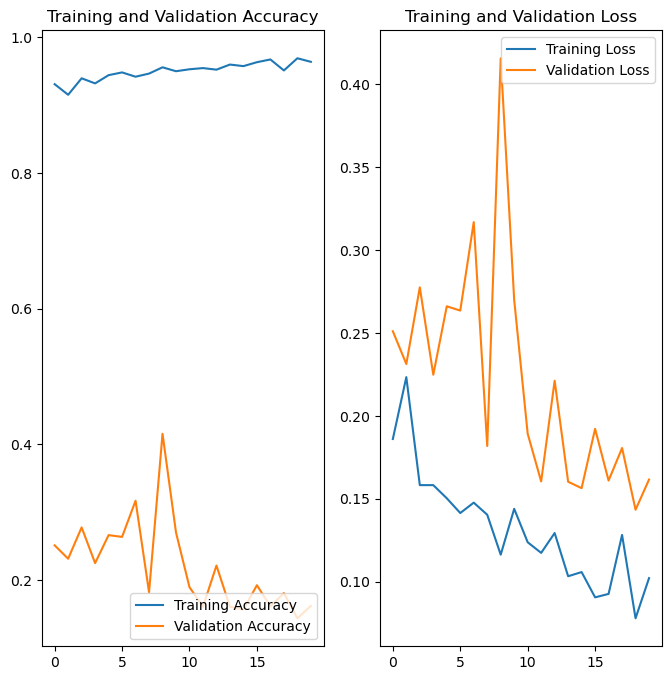

In [30]:
history.history["loss"][:5] # show loss for first 5 epochs
acc=history.history["accuracy"]
val_acc=history.history["val_accuracy"]
loss=history.history["loss"]
val_loss=history.history["val_loss"]
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label="Training Accuracy")
plt.plot(range(EPOCHS),val_loss,label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss,label="Training Loss")
plt.plot(range(EPOCHS),val_loss,label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

Run prediction on a sample image

first image to predict
actual label : Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step
predicted label: Potato___Late_blight


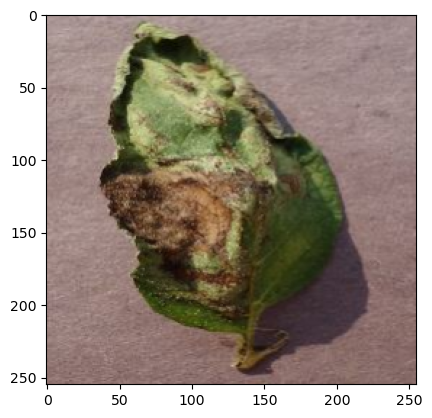

In [34]:
model=tf.keras.models.load_model("model.h5")
import numpy as np
for images_batch,label_batch in test_ds.take(1):
    first_image=images_batch[0].numpy().astype("uint8")
    first_label=label_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label :",class_names[first_label])

    batch_prediction=model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

 # WRITTING A FUCTION FOR INTERFERENCE
 

In [35]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)

    predictions=model.predict(img_array)
    predicted_class=class_names[np.argmax(predictions[0])]
    confidence=round(100* (np.max(predictions[0])),2)
    return predicted_class,confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


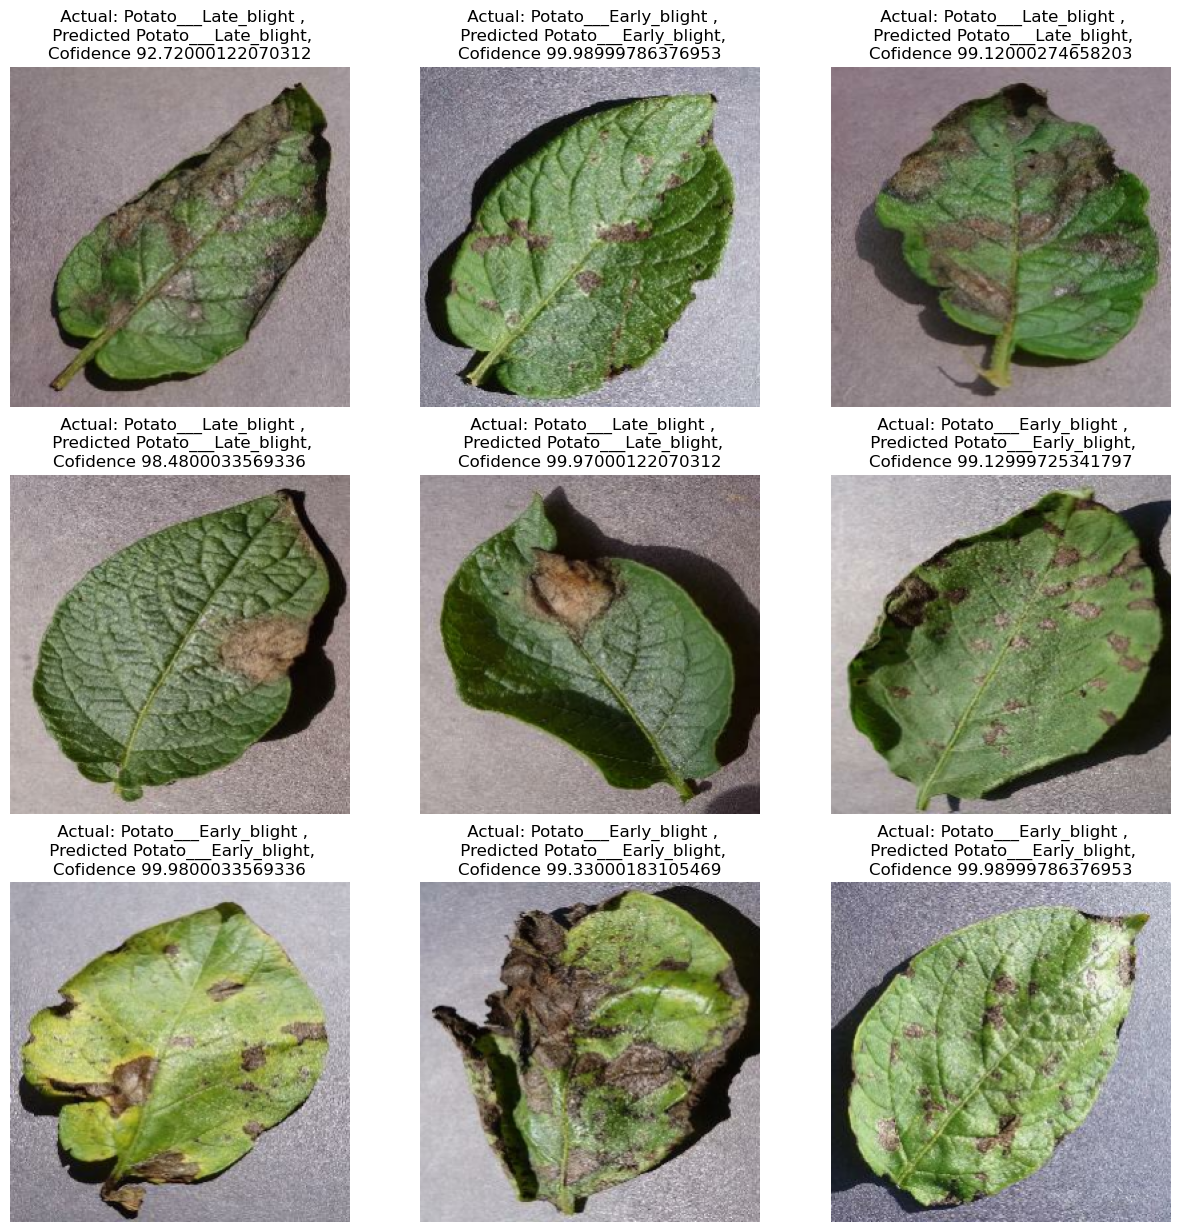

In [40]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for  i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class,confidence=predict(model,images[i].numpy())
        actual_class=class_names[labels[i]]
        plt.title(f" Actual: {actual_class} ,\n Predicted {predicted_class},\nCofidence {confidence}")

        plt.axis("off")